In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
from matplotlib import pyplot as plt
plt.rcParams['font.family']='Times New Roman,Microsoft YaHei'# 设置字体族，中文为微软雅黑，英文为Times New Roman
plt.rcParams['mathtext.fontset'] = 'stix' # 设置数%matplotlib qt学公式字体为stix
plt.style.use('seaborn-v0_8-paper')
# 设置全局参数
plt.rcParams['figure.facecolor'] = 'white'  # 设置图形的背景为透明
plt.rcParams['axes.facecolor'] = 'white'    # 设置轴域的背景为透明
plt.rcParams['savefig.facecolor'] = 'white' # 保存图像时背景透明
import matplotlib
# matplotlib.use('TkAgg')
%matplotlib inline

In [ ]:
dfmusic = pd.read_pickle("df_chordkey,pkl")
dfbird = pd.read_pickle('final_birds_df.pkl')
dfclasse = pd.read_pickle('final_classes_df.pkl')

In [2]:
df=pd.read_pickle("music_var_tempo.pkl")

In [3]:
df = df.loc[:, ~df.columns.duplicated()]

# 定义高度替换规则
def replace_level(row):
    if row['place'] == 'ZS':
        return '3 m' if row['level'] == 1 else f"{row['level']}m"
    elif row['place'] == 'JH':
        return {1: '1.5 m', 2: '4 m', 3: '8 m', 4: '14 m'}.get(row['level'], f"{row['level']}m")
    elif row['place'] == 'CM':
        return {1: '1.5 m', 2: '10 m', 3: '16 m', 4: '22 m'}.get(row['level'], f"{row['level']}m")
    return f"{row['level']}m"

# 替换 level 列的值
df['level'] = df.apply(replace_level, axis=1)

In [4]:
import ast
def get_highest_tempo(tempo_estimates_str):
    try:
        # 将字符串转换为集合
        tempo_estimates_str = tempo_estimates_str.replace('{', '[').replace('}', ']')  # 将集合形式转换为列表形式
        tempos = ast.literal_eval(tempo_estimates_str)
        
        if isinstance(tempos, list):
            # 转换为 NumPy 数组
            tempos_array = np.array(tempos)
            
            # 提取权重列
            weights = tempos_array[:, 1].astype(float)
            # 提取节奏列
            tempos_values = tempos_array[:, 0].astype(float)
            
            # 找到权重最高的节奏
            highest_index = np.argmax(weights)
            highest_tempo = tempos_values[highest_index]
            return highest_tempo
        else:
            print(f"Error: Expected a list, but got a different type: {type(tempos)}")
            return None
    except (ValueError, SyntaxError, TypeError) as e:
        # 处理解析错误或格式错误
        print(f"Error processing {tempo_estimates_str}: {e}")
        return None
    
    
# 应用 get_highest_tempo 函数
df['tempo'] = df['Tempo_Estimates'].apply(get_highest_tempo)

# 删除原始的 Tempo_Estimates 列
df = df.drop(columns=['Tempo_Estimates'])

In [5]:
df.columns

Index(['Date', 'place', 'level', 'Onsets', 'tempo'], dtype='object')

In [6]:
import pickle
from scipy import stats

# 将 Date 列转换为 datetime 类型并提取 Month
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month

# 计算节奏的平均值并记录到字典中   
mean_dict = {}
for (place, level, month), group in df.groupby(['place', 'level', 'Month']):
    mean_tempo = group['tempo'].mean()  # 计算平均值
    std_tempo = group['tempo'].std()  # 计算标准差
    mean_dict[f'{place}_{level}_{month}_mean'] = mean_tempo
    mean_dict[f'{place}_{level}_{month}_std'] = std_tempo
# 定义保存路径
file_path = 'mean_tempo.pkl'

# 保存字典到 pkl 文件
with open(file_path, 'wb') as file:
    pickle.dump(mean_dict, file)


In [7]:
# 转换月份为英文简写
df['Month'] = pd.to_datetime(df['Month'], format='%m').dt.strftime('%b')

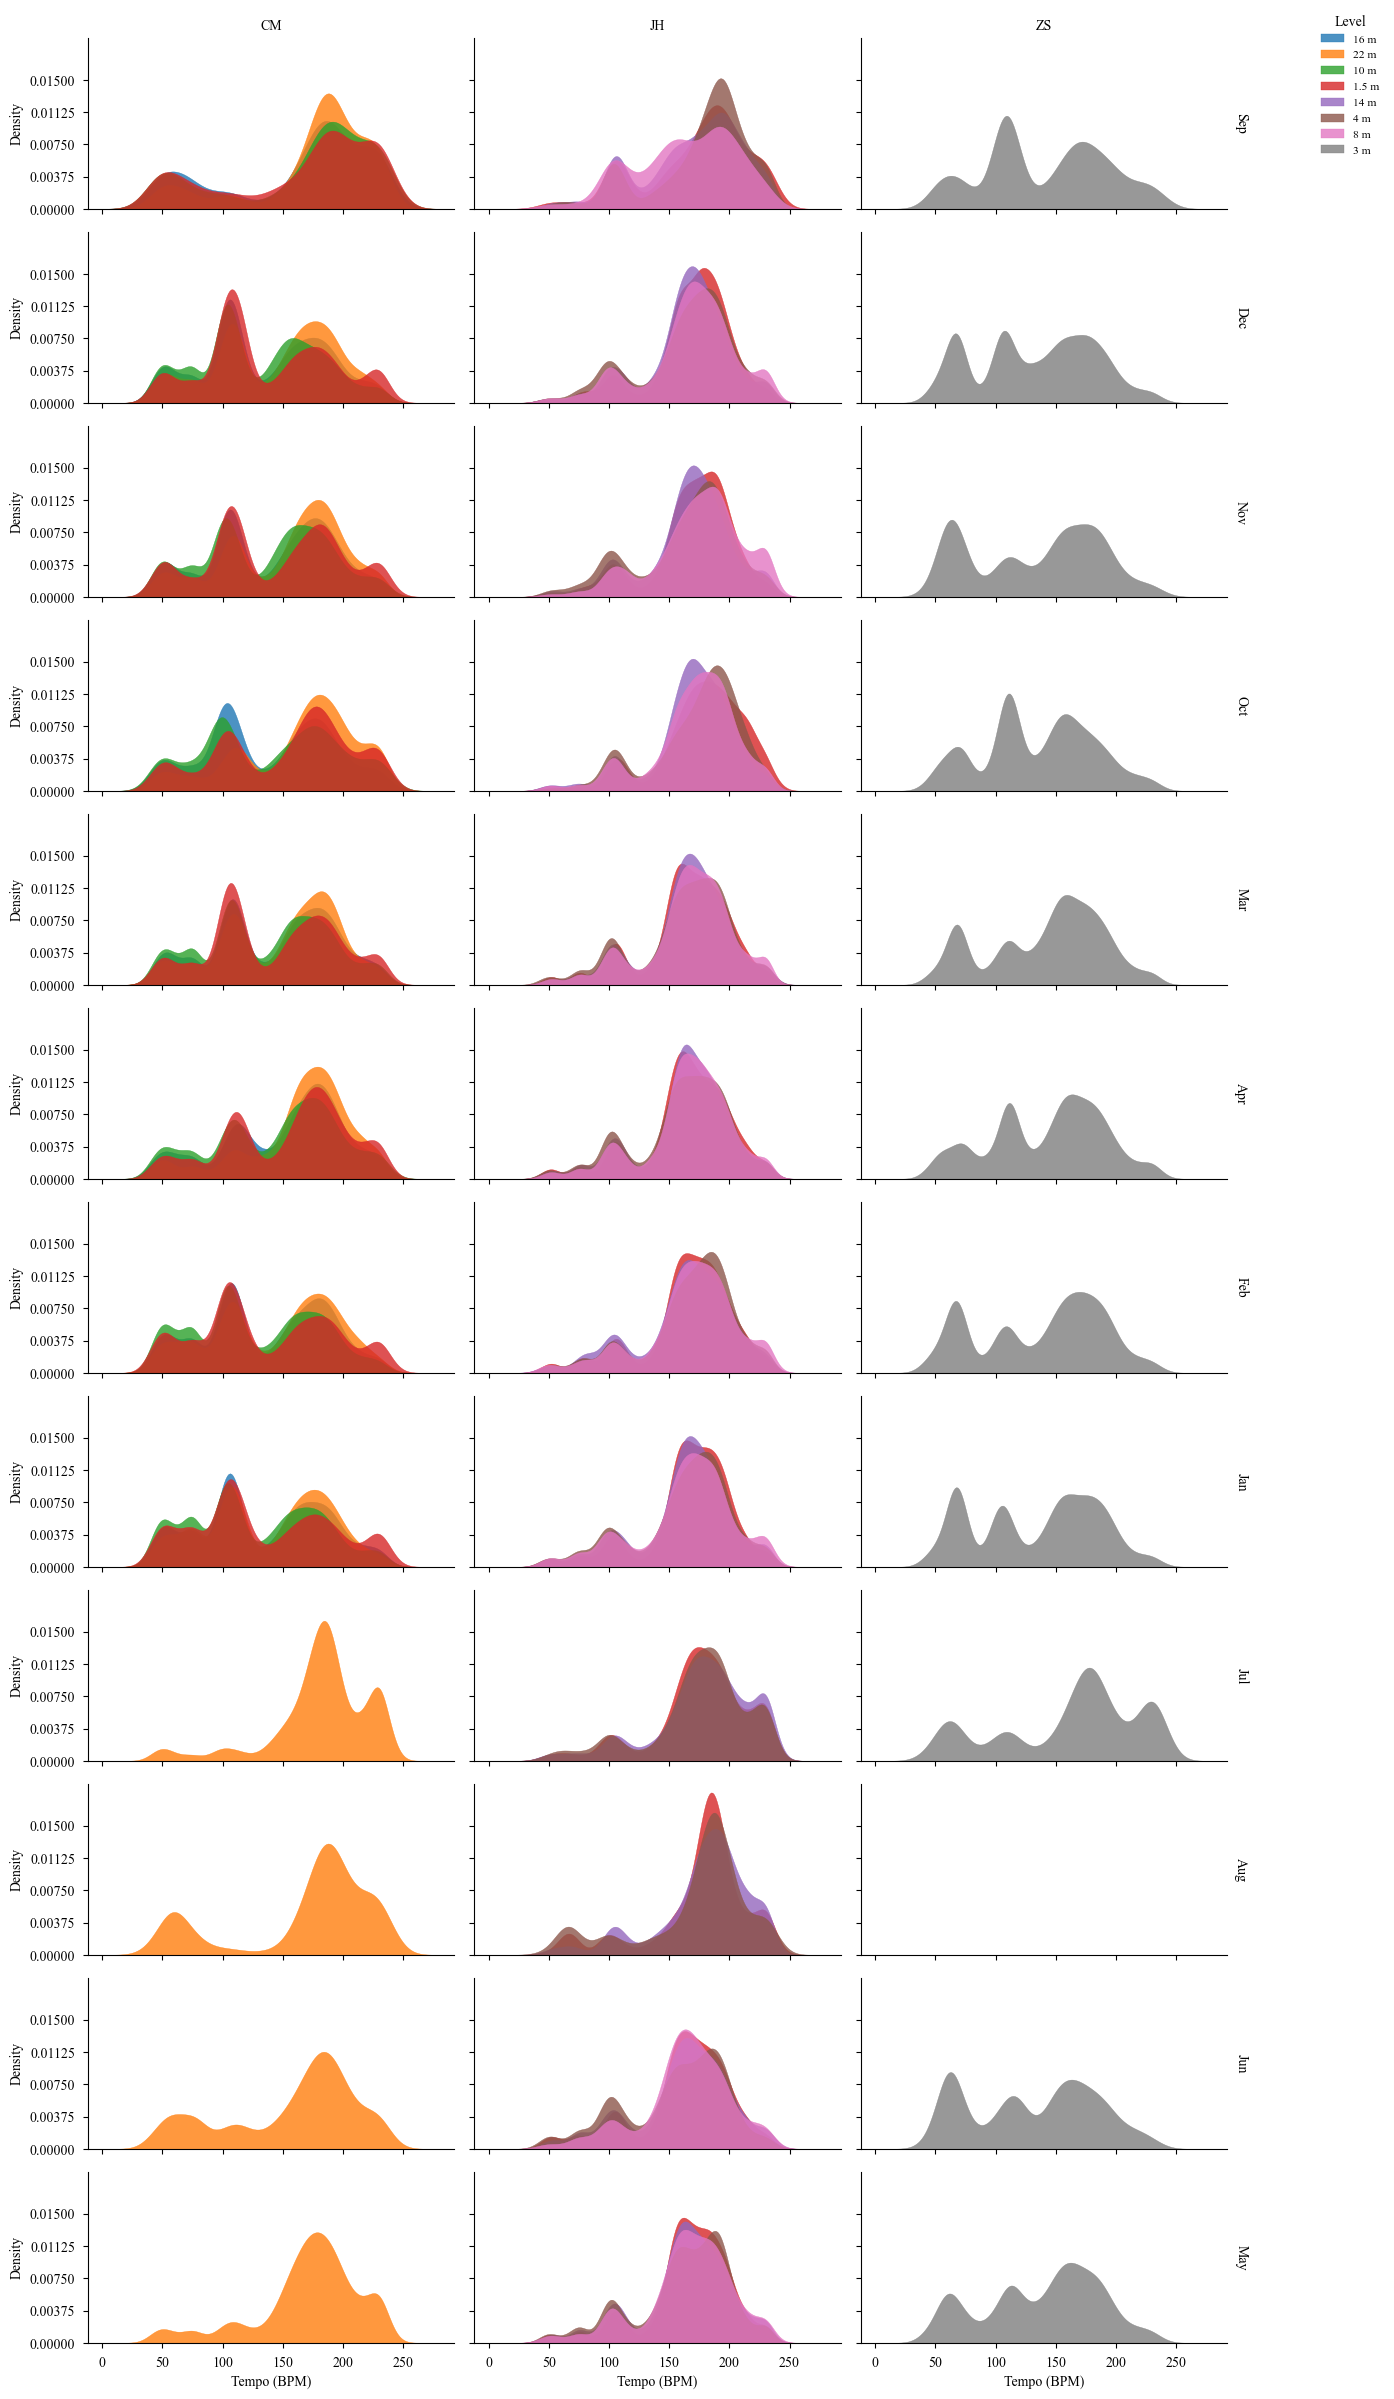

In [8]:
from palettable.tableau import GreenOrange_12

# 创建一个 FaetGrid 对象
g = sns.FacetGrid(df, col="place", row="Month", hue="level", margin_titles=True, dropna=True, height=2, aspect=2)
# 将 kdeplot 映射到每个子图
g = g.map(sns.kdeplot, "tempo", fill=True, common_norm=False, alpha=0.8,cmap=GreenOrange_12.mpl_colormap)
# 添加图例，并指定图例的位置和大小
g.add_legend(title="Level", fontsize='small', title_fontsize='medium', loc='upper right', bbox_to_anchor=(1.1, 1))
# 设置子图标题的格式，确保边距和对齐方式符合期刊的排版要求
g.set_titles(row_template='{row_name}', col_template='{col_name}', size='medium')
# 设置坐标轴标签，包括字体大小和标签内容
g.set_axis_labels("Tempo (BPM)", "Density", size='medium')
# 优化坐标轴刻度，使其更加精细和适应数据分布
g.set(yticks=np.linspace(0, 0.015, 5))

# 设置所有刻度标签的大小
for ax in g.axes.flatten():
    ax.tick_params(axis='both', which='major', labelsize=10)  # 调整主要刻度的大小
    
# 使用更紧凑的布局来确保所有子图和标签都在页面内可见
plt.tight_layout()
# 保存图像，指定足够的分辨率
plt.savefig("tempo_distribution.png", dpi=500)
plt.savefig("tempo_distribution.svg")
# 显示图
plt.show()

In [9]:
# 分组并聚合计算
grouped_stats = df.groupby(['place', 'Month', 'level'])['tempo'].agg(
    Mean='mean',
    Std='std',
    Max='max',
    Min='min'
).reset_index()

In [10]:
# 或保存为 Excel 文件
grouped_stats.to_excel("tempo_statistics.xlsx", index=False)

In [11]:
# # 转换字符串到 NumPy 数组
# df['Onsets'] = df['Onsets'].apply(lambda x: np.fromstring(x.strip('{}'), sep=','))

In [12]:
# # 计算全局平均趋势，首先确定所有数组长度一致
# min_length = min(len(x) for x in df['Onsets'])
# df['Onsets'] = df['Onsets'].apply(lambda x: x[:min_length])
# global_mean = df['Onsets'].apply(pd.Series).mean()

In [13]:

# # 创建一个 FacetGrid，根据 place 和 month 分类
# g = sns.FacetGrid(df, col="Month", row="place", hue="level", palette="viridis", 
#                   margin_titles=True, height=4, aspect=2)
# 
# # 绘制每个 level 的 200 个随机样本
# def plot_samples(data, color, label, **kwargs):
#     # 随机选择 200 个样本，并降低透明度
#     sample_data = data.sample(n=200, random_state=42)
#     for _, row in sample_data.iterrows():
#         plt.plot(row['Onsets'], color=color, alpha=0.3, linewidth=0.5)
# 
# # 映射上述函数到每个子图
# g.map_dataframe(plot_samples)
# 
# # 在每个子图中绘制总平均趋势
# g.map(plt.plot, global_mean, color="red", linewidth=2, label="Global Mean")
# 
# # 添加图例和美化图表
# g.add_legend(title="Level")
# g.set_axis_labels("Index", "Onsets Value")
# g.set_titles("{col_name} | {row_name}")
# 
# plt.tight_layout()
# plt.show()